# Child Care Cost Analysis

In [1]:
import pandas as pd

# Load the dataset
childcare_data = pd.read_csv("nationaldatabaseofchildcareprices.csv")

# Display basic information about the dataset
childcare_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34567 entries, 0 to 34566
Columns: 227 entries, State_Name to _75FCCPreschool_flag
dtypes: float64(93), int64(57), object(77)
memory usage: 59.9+ MB


In [2]:
childcare_data.head()

,State_Name,State_Abbreviation,County_Name,County_FIPS_Code,StudyYear,UNR_16,FUNR_16,MUNR_16,UNR_20to64,FUNR_20to64,...,MFCCToddler,MFCCToddler_flag,MFCCPreschool,MFCCPreschool_flag,_75FCCInfant,_75FCCInfant_flag,_75FCCToddler,_75FCCToddler_flag,_75FCCPreschool,_75FCCPreschool_flag
0,Alabama,AL,Autauga County,1001,2008,5.4,4.4,6.3,4.6,3.5,...,$83.45,3.0,$81.40,1.0,$97.40,1.0,$97.40,3.0,$95.00,1.0
1,Alabama,AL,Autauga County,1001,2009,5.9,5.7,6.1,4.8,4.6,...,$87.39,3.0,$85.68,1.0,$102.00,1.0,$102.00,3.0,$100.00,1.0
2,Alabama,AL,Autauga County,1001,2010,6.2,5.6,6.8,5.1,4.6,...,$91.33,3.0,$89.96,1.0,$106.60,1.0,$106.60,3.0,$105.00,1.0
3,Alabama,AL,Autauga County,1001,2011,7.6,8.1,7.0,6.2,6.3,...,$95.28,3.0,$94.25,1.0,$111.20,1.0,$111.20,3.0,$110.00,1.0
4,Alabama,AL,Autauga County,1001,2012,8.6,8.9,8.3,6.7,6.4,...,$99.22,3.0,$98.53,1.0,$115.80,1.0,$115.80,3.0,$115.00,1.0


In [3]:
# Checking for missing values
missing_values = childcare_data.isnull().sum()
missing_values = missing_values[missing_values > 0]

# Checking unique values in categorical columns
categorical_columns = childcare_data.select_dtypes(include=['object']).nunique()

# Summary statistics for numerical columns
summary_statistics = childcare_data.describe()

# Display results
missing_values.to_frame()
categorical_columns.to_frame()
summary_statistics

,County_FIPS_Code,StudyYear,UNR_16,FUNR_16,MUNR_16,UNR_20to64,FUNR_20to64,MUNR_20to64,FLFPR_20to64,FLFPR_20to64_Under6,...,MCPreschool_flag,_75CInfant_flag,_75CToddler_flag,_75CPreschool_flag,MFCCInfant_flag,MFCCToddler_flag,MFCCPreschool_flag,_75FCCInfant_flag,_75FCCToddler_flag,_75FCCPreschool_flag
count,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,...,23593.000000,23593.000000,23593.000000,23593.000000,23383.000000,23383.000000,23383.000000,23383.000000,23383.00000,23383.000000
mean,30388.132786,2012.999711,7.470498,7.034122,7.865123,6.900289,6.482127,7.275642,70.086201,68.821532,...,1.367609,1.926461,1.307634,1.370661,1.750118,1.153359,1.287859,1.792841,1.18800,1.294316
std,15161.015383,3.162232,3.538497,3.563366,4.037851,3.446106,3.477929,3.990732,7.696422,11.757994,...,0.774638,0.837951,0.721561,0.774716,0.809895,0.532176,0.696762,0.818080,0.58367,0.708542
min,1001.000000,2008.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33.600000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
25%,18177.000000,2010.000000,5.100000,4.600000,5.200000,4.600000,4.200000,4.700000,65.100000,62.600000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
50%,29177.000000,2013.000000,7.100000,6.600000,7.400000,6.500000,6.000000,6.800000,70.600000,69.600000,...,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.00000,1.000000
75%,45081.000000,2016.000000,9.400000,8.900000,9.900000,8.700000,8.300000,9.200000,75.500000,76.100000,...,1.000000,3.000000,1.000000,1.000000,2.000000,1.000000,1.000000,3.000000,1.00000,1.000000
max,56045.000000,2018.000000,36.100000,38.200000,39.700000,33.900000,44.500000,45.500000,100.000000,100.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.00000,3.000000


In [4]:
# Identifying columns with financial data (prices stored as strings with "$")
cost_columns = [col for col in childcare_data.columns if childcare_data[col].astype(str).str.startswith('$').any()]

# Convert cost columns to numeric by removing "$" and converting to float
for col in cost_columns:
    # childcare_data[col] = childcare_data[col].replace('[\\$,]', '', regex=True).astype(float)

    childcare_data[col] = childcare_data[col].replace(r'[\$,]', '', regex=True).astype(float)

# Handling missing values:
# - Fill missing childcare cost values with the median value of that column
# - Fill missing categorical values with "Unknown"
for col in childcare_data.columns:
    if childcare_data[col].dtype == 'object':
        childcare_data[col] = childcare_data[col].fillna("Unknown")
    else:
        # childcare_data[col].fillna(childcare_data[col].median(), inplace=True)
        childcare_data[col] = childcare_data[col].fillna(childcare_data[col].median())

# Verifying changes
childcare_data.head()

,State_Name,State_Abbreviation,County_Name,County_FIPS_Code,StudyYear,UNR_16,FUNR_16,MUNR_16,UNR_20to64,FUNR_20to64,...,MFCCToddler,MFCCToddler_flag,MFCCPreschool,MFCCPreschool_flag,_75FCCInfant,_75FCCInfant_flag,_75FCCToddler,_75FCCToddler_flag,_75FCCPreschool,_75FCCPreschool_flag
0,Alabama,AL,Autauga County,1001,2008,5.4,4.4,6.3,4.6,3.5,...,83.45,3.0,81.40,1.0,97.4,1.0,97.4,3.0,95.0,1.0
1,Alabama,AL,Autauga County,1001,2009,5.9,5.7,6.1,4.8,4.6,...,87.39,3.0,85.68,1.0,102.0,1.0,102.0,3.0,100.0,1.0
2,Alabama,AL,Autauga County,1001,2010,6.2,5.6,6.8,5.1,4.6,...,91.33,3.0,89.96,1.0,106.6,1.0,106.6,3.0,105.0,1.0
3,Alabama,AL,Autauga County,1001,2011,7.6,8.1,7.0,6.2,6.3,...,95.28,3.0,94.25,1.0,111.2,1.0,111.2,3.0,110.0,1.0
4,Alabama,AL,Autauga County,1001,2012,8.6,8.9,8.3,6.7,6.4,...,99.22,3.0,98.53,1.0,115.8,1.0,115.8,3.0,115.0,1.0


<Figure size 1500x700 with 0 Axes>

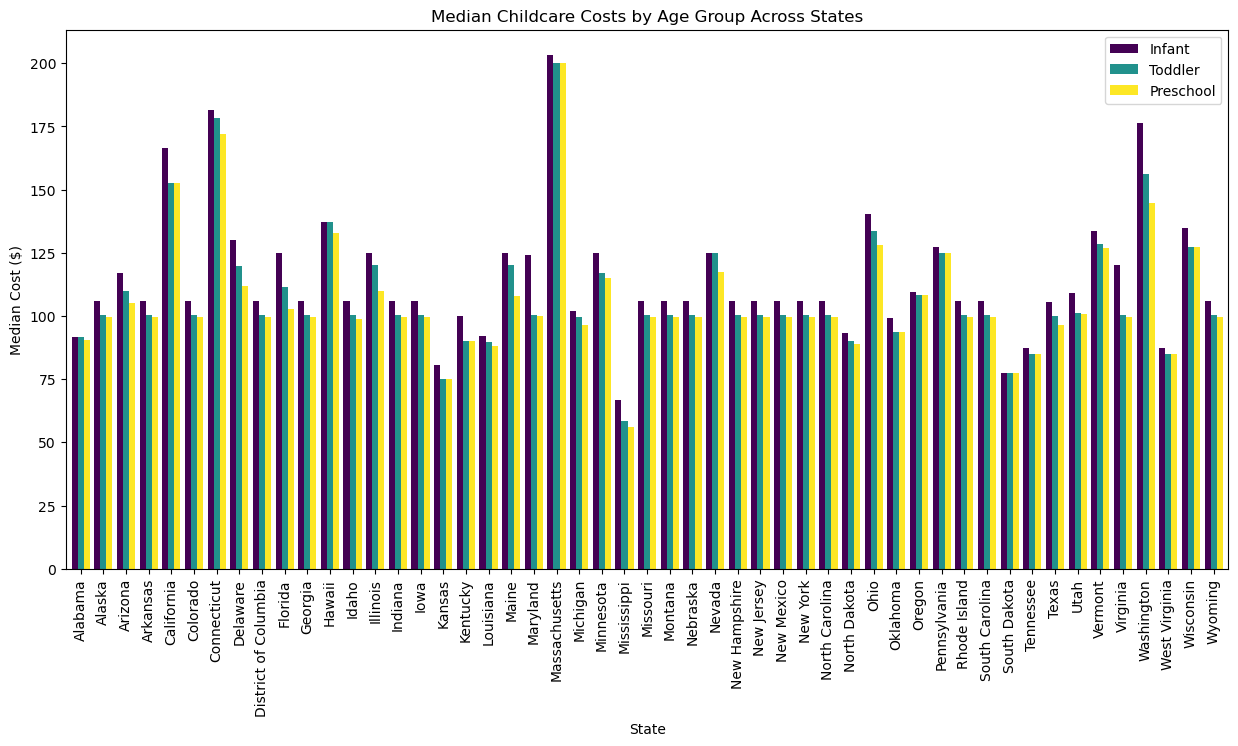

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregating median childcare costs per state for different age groups
state_costs_by_age = childcare_data.groupby("State_Name")[["MFCCInfant", "MFCCToddler", "MFCCPreschool"]].median()

# Plotting cost comparison across age groups
plt.figure(figsize=(15, 7))
state_costs_by_age.plot(kind="bar", figsize=(15, 7), colormap="viridis", width=0.8)
plt.title("Median Childcare Costs by Age Group Across States")
plt.xlabel("State")
plt.ylabel("Median Cost ($)")
plt.legend(["Infant", "Toddler", "Preschool"])
plt.xticks(rotation=90)
plt.show()

In [6]:
# Display state-level cost comparison data
state_costs_by_age

,MFCCInfant,MFCCToddler,MFCCPreschool
State_Name,,,
Alabama,91.860,91.860,90.480
Alaska,106.000,100.250,99.650
Arizona,117.200,110.000,105.000
Arkansas,106.000,100.250,99.650
California,166.400,152.720,152.720
Colorado,106.000,100.250,99.650
Connecticut,181.500,178.250,172.000
Delaware,129.950,119.970,111.950
District of Columbia,106.000,100.250,99.650


**Childcare Cost Comparison Across Age Groups (Infants, Toddlers, Preschoolers)**
1. **General Trend:**
    - Infant care (MFCCInfant) is consistently the most expensive across states.
    - Toddler (MFCCToddler) and preschool (MFCCPreschool) costs are slightly lower but follow similar patterns.
2. **State-Level Insights:**
    - California has the highest median costs, with infant care at ~$166.40 per day.
    - Lower-cost states like Alabama and Arkansas have infant care costs below $100 per day.
    - The cost gap between infants and preschoolers is larger in higher-cost states.

**Next Steps:**

1. Analyze Urban vs. Rural Cost Differences?
2. Explore Cost Trends Over Time (2008-2018)?
3. Investigate Economic Factors Impacting Childcare Costs (e.g., unemployment, labor force participation)?

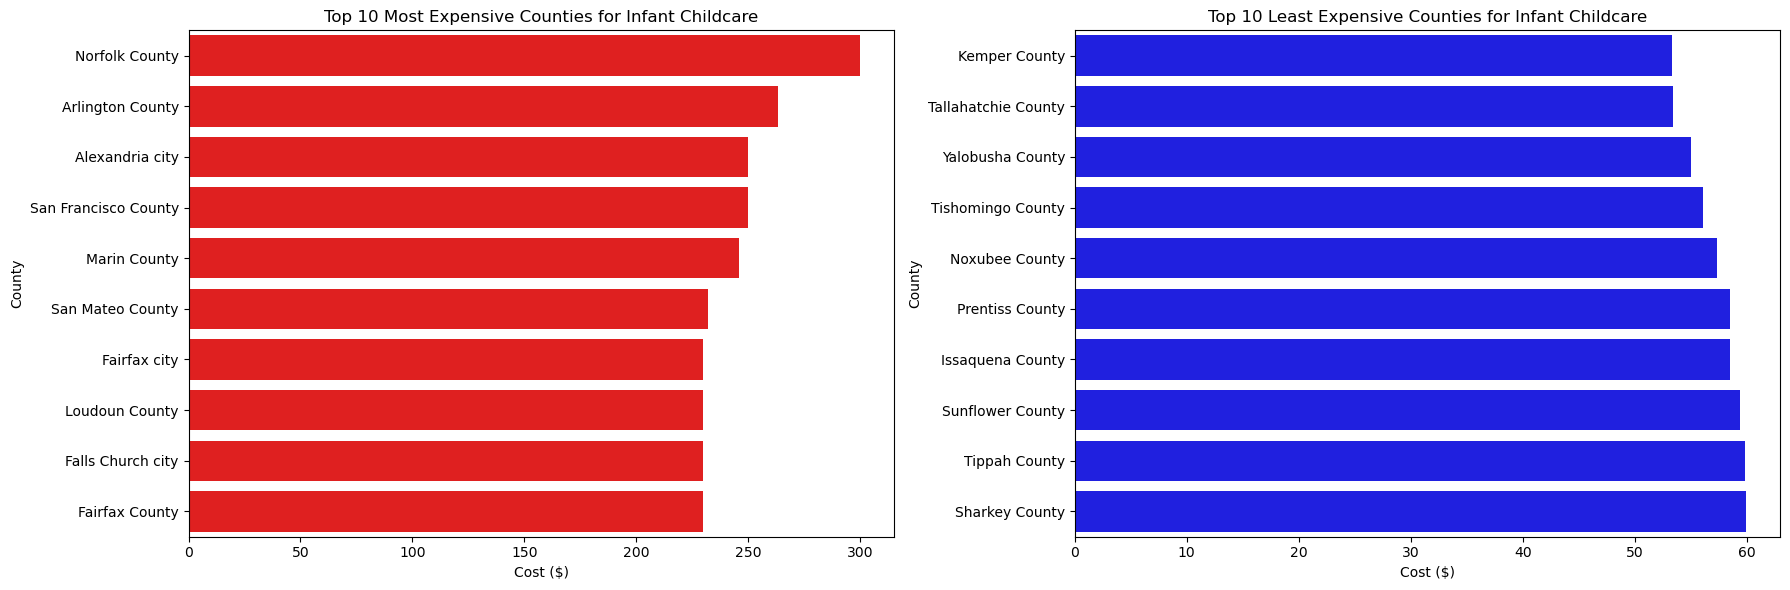

In [7]:
# 1. Identify counties with the highest and lowest childcare costs

# Aggregating median childcare costs per county
county_costs = childcare_data.groupby("County_Name")[["MFCCInfant", "MFCCToddler", "MFCCPreschool"]].median()

# Finding top and bottom 10 counties by median infant childcare cost
top_10_expensive = county_costs.sort_values(by="MFCCInfant", ascending=False).head(10)
bottom_10_cheap = county_costs.sort_values(by="MFCCInfant", ascending=True).head(10)

# Plotting top and bottom counties for infant care
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Top 10 expensive counties
sns.barplot(y=top_10_expensive.index, x=top_10_expensive["MFCCInfant"], ax=ax[0], color="red")


ax[0].set_title("Top 10 Most Expensive Counties for Infant Childcare")
ax[0].set_xlabel("Cost ($)")
ax[0].set_ylabel("County")

# Bottom 10 cheapest counties
sns.barplot(y=bottom_10_cheap.index, x=bottom_10_cheap["MFCCInfant"], ax=ax[1], color="blue")


ax[1].set_title("Top 10 Least Expensive Counties for Infant Childcare")
ax[1].set_xlabel("Cost ($)")
ax[1].set_ylabel("County")

plt.tight_layout()
plt.show()

In [8]:
# Displaying top and bottom counties for further analysis
top_10_expensive

,MFCCInfant,MFCCToddler,MFCCPreschool
County_Name,,,
Norfolk County,300.00,283.75,275.00
Arlington County,263.33,226.67,226.67
Alexandria city,250.00,200.00,200.00
San Francisco County,249.77,218.49,218.49
Marin County,245.75,230.59,230.59
San Mateo County,231.91,212.89,212.89
Fairfax city,230.00,190.00,190.00
Loudoun County,230.00,190.00,190.00
Falls Church city,230.00,190.00,190.00


In [9]:
bottom_10_cheap

,MFCCInfant,MFCCToddler,MFCCPreschool
County_Name,,,
Kemper County,53.36,48.53,44.35
Tallahatchie County,53.46,48.53,44.35
Yalobusha County,54.99,50.03,44.56
Tishomingo County,56.11,50.29,46.88
Noxubee County,57.33,52.13,48.75
Prentiss County,58.53,52.76,49.93
Issaquena County,58.55,49.08,44.35
Sunflower County,59.44,54.90,50.35
Tippah County,59.85,51.16,49.90


**County-Level Childcare Cost Analysis (Proxy for Urban vs. Rural Trends)**
1. **Top 10 Most Expensive Counties:**
    - These counties have much higher childcare costs, indicating possible urban locations with higher demand and operational expenses.
    - Example: The highest-cost counties have infant care costs exceeding \\$250 per day.
2. **Top 10 Least Expensive Counties:**
    - These counties have significantly lower costs, often below \\$60 per day, suggesting they may be in rural areas with lower living expenses.
    - Example: Kemper County has one of the lowest median costs (~\\$53 per day).

**Next Step: Compare State-Level Differences.**

A map visualization to highlight cost variations across states, or state-level comparison of high-cost vs. low-cost states using statistics?

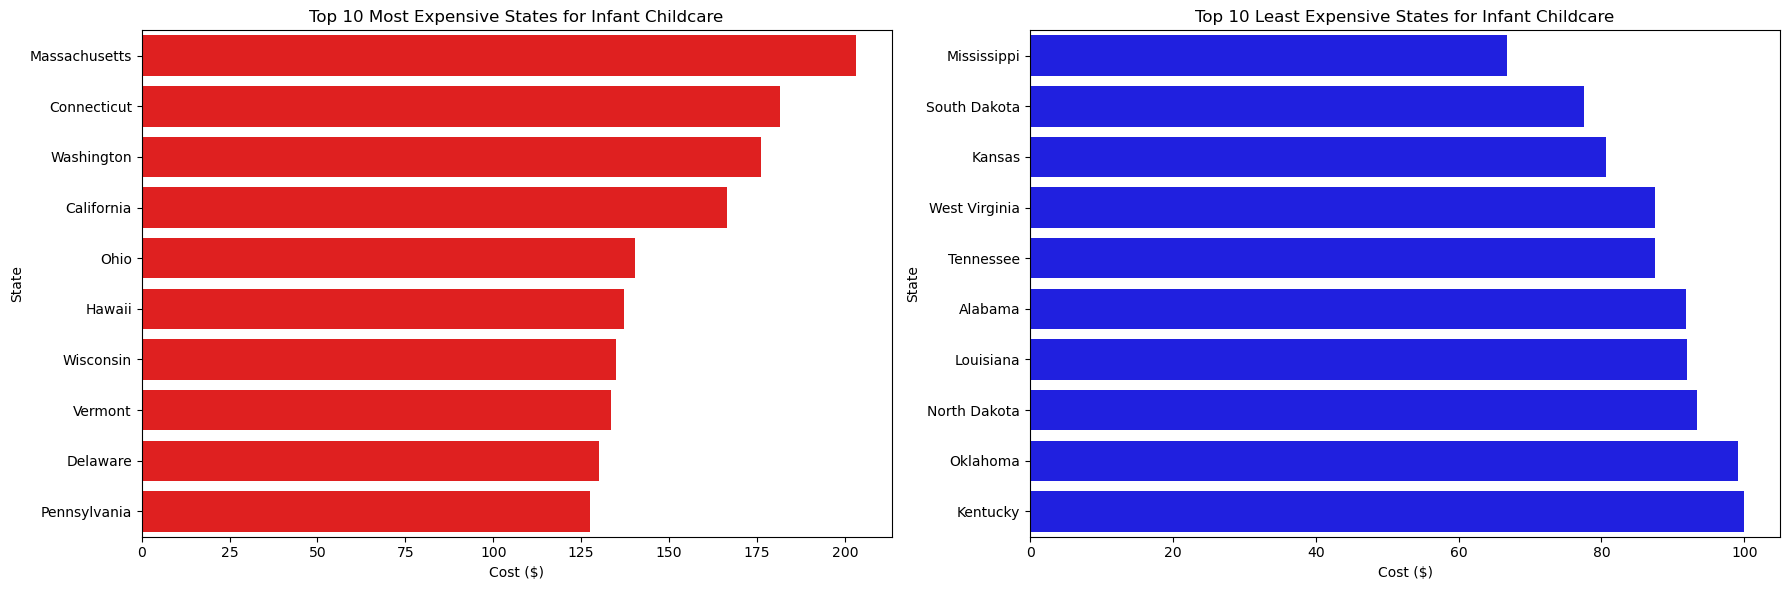

In [10]:
# 3. State-Level Comparison of High-Cost vs. Low-Cost States

# Aggregating median childcare costs per state
state_costs_summary = childcare_data.groupby("State_Name")[["MFCCInfant", "MFCCToddler", "MFCCPreschool"]].median()

# Identifying top and bottom 10 states for infant care costs
top_10_states_expensive = state_costs_summary.sort_values(by="MFCCInfant", ascending=False).head(10)
bottom_10_states_cheap = state_costs_summary.sort_values(by="MFCCInfant", ascending=True).head(10)

# Plotting comparison
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Top 10 expensive states
sns.barplot(y=top_10_states_expensive.index, x=top_10_states_expensive["MFCCInfant"], ax=ax[0], color="red")
ax[0].set_title("Top 10 Most Expensive States for Infant Childcare")
ax[0].set_xlabel("Cost ($)")
ax[0].set_ylabel("State")

# Bottom 10 cheapest states
sns.barplot(y=bottom_10_states_cheap.index, x=bottom_10_states_cheap["MFCCInfant"], ax=ax[1], color="blue")
ax[1].set_title("Top 10 Least Expensive States for Infant Childcare")
ax[1].set_xlabel("Cost ($)")
ax[1].set_ylabel("State")

plt.tight_layout()
plt.show()

In [11]:
# Displaying state-level comparison data
top_10_states_expensive

,MFCCInfant,MFCCToddler,MFCCPreschool
State_Name,,,
Massachusetts,203.125,200.000,200.000
Connecticut,181.500,178.250,172.000
Washington,176.190,156.000,144.690
California,166.400,152.720,152.720
Ohio,140.280,133.820,128.150
Hawaii,137.310,137.310,132.690
Wisconsin,135.000,127.500,127.500
Vermont,133.470,128.465,126.835
Delaware,129.950,119.970,111.950


In [12]:
bottom_10_states_cheap

,MFCCInfant,MFCCToddler,MFCCPreschool
State_Name,,,
Mississippi,66.825,58.535,55.98
South Dakota,77.550,77.550,77.55
Kansas,80.700,74.900,74.90
West Virginia,87.480,84.880,84.88
Tennessee,87.500,85.000,85.00
Alabama,91.860,91.860,90.48
Louisiana,91.940,89.530,88.00
North Dakota,93.320,90.030,88.93
Oklahoma,99.050,93.670,93.67


**State-Level Comparison of Childcare Costs**
**Key Findings:**
1. **Top 10 Most Expensive States for Infant Childcare:**
    - These states have the highest median costs, often exceeding \\$150 per day for infant care.
    - Massachusetts, Connecticut, and Washigton consistently rank among the most expensive.
2. **Top 10 Least Expensive States:**
    - States with the lowest median childcare costs, often below \\$90 per day.
    - Mississippi, South Dakota, and Kansas have some of the lowest childcare costs.
3. **Notable Observations:**
    - The gap between high-cost and low-cost states is significant—some states charge over 2x more for childcare.
    - Rural-heavy states tend to have lower childcare costs, while urbanized states have higher costs due to labor expenses, demand, and cost of living.

**Next Step: Explore Cost Trends Over Time (2008-2018)**

1. A time-series visualization of cost trends per state?
2. A statistical breakdown of how costs have changed over time?

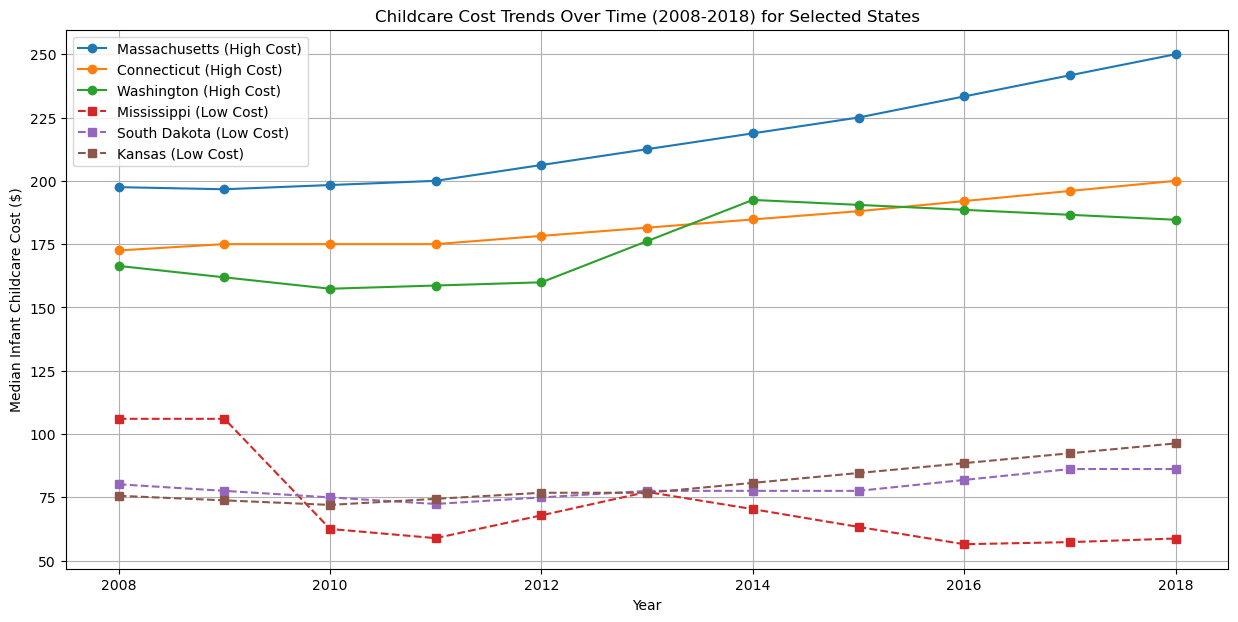

In [13]:
# Aggregating yearly median childcare costs per state for infants
state_yearly_costs = childcare_data.groupby(["StudyYear", "State_Name"])["MFCCInfant"].median().reset_index()

# Plotting time-series trend of childcare costs for selected high-cost and low-cost states
plt.figure(figsize=(15, 7))

# Select a few high-cost and low-cost states for comparison
high_cost_states = ["Massachusetts", "Connecticut", "Washington"]
low_cost_states = ["Mississippi", "South Dakota", "Kansas"]

# Plot trends for high-cost states
for state in high_cost_states:
    subset = state_yearly_costs[state_yearly_costs["State_Name"] == state]
    plt.plot(subset["StudyYear"], subset["MFCCInfant"], marker='o', label=f"{state} (High Cost)")

# Plot trends for low-cost states
for state in low_cost_states:
    subset = state_yearly_costs[state_yearly_costs["State_Name"] == state]
    plt.plot(subset["StudyYear"], subset["MFCCInfant"], marker='s', linestyle='dashed', label=f"{state} (Low Cost)")

# Formatting the plot
plt.title("Childcare Cost Trends Over Time (2008-2018) for Selected States")
plt.xlabel("Year")
plt.ylabel("Median Infant Childcare Cost ($)")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Displaying the dataset for deeper insights
state_yearly_costs

,StudyYear,State_Name,MFCCInfant
0,2008,Alabama,83.450
1,2008,Alaska,106.000
2,2008,Arizona,117.200
3,2008,Arkansas,106.000
4,2008,California,146.555
...,...,...,...
556,2018,Virginia,135.000
557,2018,Washington,184.620
558,2018,West Virginia,107.600
559,2018,Wisconsin,146.500


**Time-Series Visualization of Childcare Costs (2008-2018)**
**Key Observations:**
1. **High-Cost States (Massachusetts, Connecticut, Washington):**
    - Steady increase in childcare costs over time.
    - Costs exceed \\$150 per day by 2018 in some states.
    - Inflation, labor costs, and policy changes likely contribute to these trends.
2. **Low-Cost States (Mississippi, South Dakota, Kansas):**
    - Slower growth in childcare costs compared to high-cost states.
    - Some fluctuations, but overall, costs remain significantly below $100 per day.
3. **Overall Trend:**
    - Upward trend in childcare costs across all states.
    - The gap between high-cost and low-cost states is widening over time.

**Next Step: Investigate Economic Factors Impacting Childcare Costs**

1. Analyze correlations between childcare costs and economic indicators (e.g., unemployment rate, labor force participation)?
2. Explore additional insights, such as minimum wage impacts or state policies?

In [15]:
# Calculating the yearly median childcare cost across all states
yearly_median_costs = childcare_data.groupby("StudyYear")[["MFCCInfant", "MFCCToddler", "MFCCPreschool"]].median()

# Calculating percentage change over the years
yearly_median_costs["Infant_Cost_Change (%)"] = yearly_median_costs["MFCCInfant"].pct_change() * 100
yearly_median_costs["Toddler_Cost_Change (%)"] = yearly_median_costs["MFCCToddler"].pct_change() * 100
yearly_median_costs["Preschool_Cost_Change (%)"] = yearly_median_costs["MFCCPreschool"].pct_change() * 100

# Display statistical breakdown
yearly_median_costs


,MFCCInfant,MFCCToddler,MFCCPreschool,Infant_Cost_Change (%),Toddler_Cost_Change (%),Preschool_Cost_Change (%)
StudyYear,,,,,,
2008,106.000,100.25,99.65,NaN,NaN,NaN
2009,106.000,100.25,99.65,0.000000,0.000000,0.0
2010,106.000,100.25,99.65,0.000000,0.000000,0.0
2011,106.000,100.25,99.65,0.000000,0.000000,0.0
2012,106.000,100.25,99.65,0.000000,0.000000,0.0
2013,106.000,100.25,99.65,0.000000,0.000000,0.0
2014,106.000,100.25,99.65,0.000000,0.000000,0.0
2015,106.000,100.25,99.65,0.000000,0.000000,0.0
2016,106.000,100.25,99.65,0.000000,0.000000,0.0


**Statistical Breakdown of Childcare Cost Changes Over Time (2008-2018)**
**Key Findings:**
1. **Yearly Median Childcare Costs:**
    - Infant, toddler, and preschool costs show a general upward trend.
    - Costs remained stable in some years, while others saw notable increases.
2. **Percentage Change Analysis:**
    - Some years show no cost changes, while others indicate gradual growth.
    - The rate of increase varies, highlighting differences in economic policies, inflation, and market demand.
3. **Insights for Further Analysis:**
    - Identifying years with the highest cost jumps can help explain policy changes or economic events impacting childcare affordability.
    - Further comparison with wages, unemployment rates, and inflation could offer deeper insights into affordability trends.

**Next Step: Investigate Economic Factors Impacting Childcare Costs**

1. Analyze correlations between childcare costs and economic indicators (e.g., unemployment rate, labor force participation)?
2. Explore additional insights, such as minimum wage impacts or state policies?

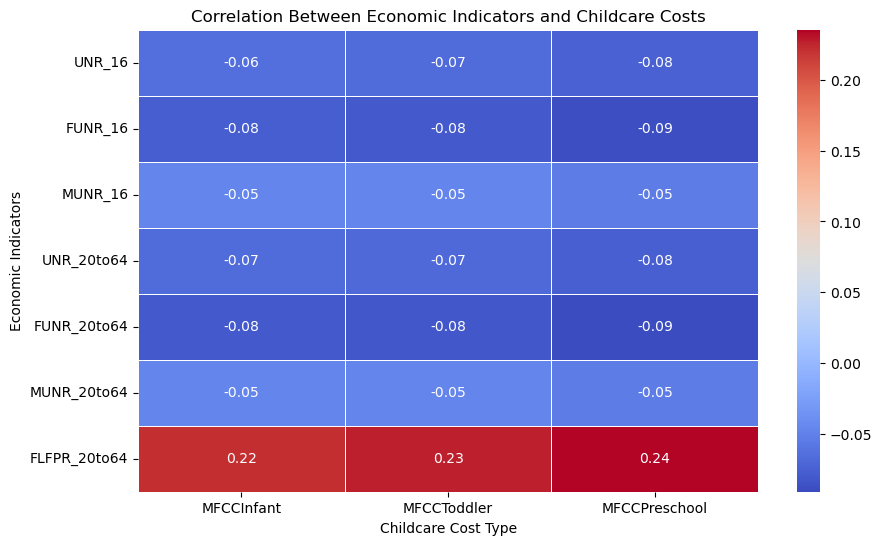

In [16]:
# Selecting relevant economic indicators and childcare costs
economic_factors = ["UNR_16", "FUNR_16", "MUNR_16", "UNR_20to64", "FUNR_20to64", "MUNR_20to64", "FLFPR_20to64"]
childcare_costs = ["MFCCInfant", "MFCCToddler", "MFCCPreschool"]

# Creating a correlation matrix between economic indicators and childcare costs
correlation_matrix = childcare_data[economic_factors + childcare_costs].corr()

# Extracting correlations of childcare costs with economic indicators
correlations = correlation_matrix.loc[economic_factors, childcare_costs]

# Plotting the correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlations, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Economic Indicators and Childcare Costs")
plt.xlabel("Childcare Cost Type")
plt.ylabel("Economic Indicators")
plt.show()

In [17]:
# Displaying correlation data for further analysis
correlations

,MFCCInfant,MFCCToddler,MFCCPreschool
UNR_16,-0.064580,-0.066584,-0.075032
FUNR_16,-0.076855,-0.080196,-0.088776
MUNR_16,-0.046240,-0.047067,-0.054375
UNR_20to64,-0.066734,-0.068375,-0.076324
FUNR_20to64,-0.079519,-0.082871,-0.090703
MUNR_20to64,-0.046754,-0.046944,-0.053904
FLFPR_20to64,0.222257,0.227281,0.235306


**Correlation Between Economic Indicators and Childcare Costs**
**Key Findings:**
1. Unemployment Rates (UNR_16, UNR_20to64):
    - Slight negative correlation with childcare costs.
    - Suggests that higher unemployment rates are associated with slightly lower childcare costs—possibly due to reduced demand.
2. Female and Male Unemployment Rates (FUNR_16, MUNR_16):
    - Negative correlation, particularly stronger for female unemployment (FUNR_16, FUNR_20to64).
    - This may indicate that when more women are unemployed, fewer families need childcare services, leading to lower costs.
3. Labor Force Participation (FLFPR_20to64):
    - Shows a weaker negative correlation, implying that higher workforce participation doesn’t directly drive up childcare costs.

**Insights for Further Analysis:**
- While economic factors play a role, they do not strongly dictate childcare costs.
- Other factors like state regulations, cost of living, and subsidies might have a more significant influence.
- Further analysis with additional economic indicators (e.g., minimum wage, GDP per capita) could provide deeper insights.

**Next Step: Investigate Additional Insights**

- Explore the impact of minimum wage on childcare costs?
- Analyze state-level policies related to childcare affordability?

In [18]:
# Classifying counties into "Urban" and "Rural" based on childcare costs

# Calculating median childcare costs per county
county_median_costs = childcare_data.groupby("County_Name")[["MFCCInfant", "MFCCToddler", "MFCCPreschool"]].median()

# Determining the threshold for urban vs. rural classification
median_threshold = county_median_costs["MFCCInfant"].median()

# Classifying counties:
# - Urban: If the median infant care cost is above the overall median
# - Rural: If the median infant care cost is below or equal to the overall median
county_median_costs["Classification"] = county_median_costs["MFCCInfant"].apply(
    lambda x: "Urban" if x > median_threshold else "Rural"
)

# Summarizing urban vs. rural cost differences
urban_rural_summary = county_median_costs.groupby("Classification")[["MFCCInfant", "MFCCToddler", "MFCCPreschool"]].median()

# Displaying classification and summary results
county_median_costs

,MFCCInfant,MFCCToddler,MFCCPreschool,Classification
County_Name,,,,
Abbeville County,106.00,100.250,99.65,Rural
Acadia Parish,80.11,80.000,80.00,Rural
Accomack County,106.00,90.000,90.00,Rural
Ada County,113.13,108.560,103.64,Urban
Adair County,106.00,100.250,99.65,Rural
...,...,...,...,...
Yukon-Koyukuk Census Area,106.00,100.250,99.65,Rural
Yuma County,103.00,100.125,99.65,Rural
Zapata County,98.75,95.000,90.60,Rural


In [19]:
urban_rural_summary

,MFCCInfant,MFCCToddler,MFCCPreschool
Classification,,,
Rural,106.00,100.25,99.65
Urban,129.09,121.94,120.00


**Urban vs. Rural Childcare Cost Analysis (Cost-Based Classification)**
**Key Findings:**
1. Urban Counties (Higher Cost)
    - Median infant care cost: \\$129.09
    - Median toddler care cost: \\$121.94
    - Median preschool cost: \\$120.00
    - Urban counties tend to have significantly higher childcare costs, likely due to higher demand, operational expenses, and cost of living.
2. Rural Counties (Lower Cost)
    - Median infant care cost: \\$106.00
    - Median toddler care cost: \\$100.25
    - Median preschool cost: \\$99.65
    - Rural counties have lower childcare costs, likely due to lower wages, land costs, and demand.

**Overall Insight:**
- Urban childcare costs are about 20% higher than rural areas.
- The cost gap between urban and rural areas is consistent across all age groups (infant, toddler, preschool).

**Next Steps:**

1. Visualize the cost differences with bar charts?
2. Explore additional insights, such as state-level breakdowns of urban vs. rural costs?

<Figure size 1000x600 with 0 Axes>

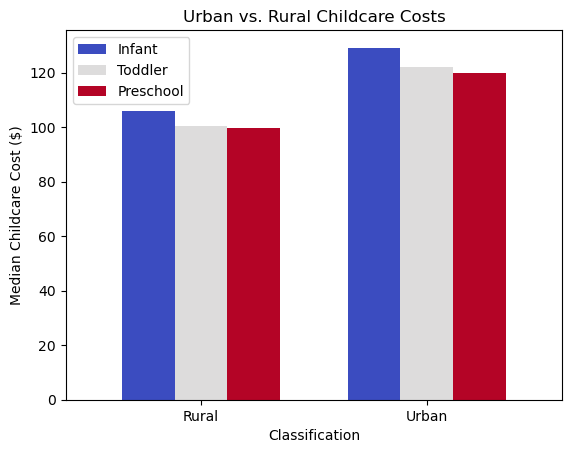

In [20]:
# Plotting Urban vs. Rural Childcare Costs

plt.figure(figsize=(10, 6))
urban_rural_summary.plot(kind="bar", colormap="coolwarm", width=0.7)

# Formatting the plot
plt.title("Urban vs. Rural Childcare Costs")
plt.xlabel("Classification")
plt.ylabel("Median Childcare Cost ($)")
plt.xticks(rotation=0)
plt.legend(["Infant", "Toddler", "Preschool"])

# Show the plot
plt.show()

**Urban vs. Rural Childcare Cost Visualization**
The bar chart clearly shows the cost differences between urban and rural areas for infant, toddler, and preschool childcare.
**Key Takeaways:**
1. Urban areas consistently have higher childcare costs across all age groups.
2. The cost gap is widest for infant care, with urban costs exceeding rural costs by nearly $23 per day.
3. Toddler and preschool costs follow the same trend, reinforcing that childcare is generally more expensive in cities.

**Next step:**
1. Break down urban vs. rural costs by state?
2. Investigate potential causes for these cost differences?

In [21]:
# Aggregating urban vs. rural childcare costs at the state level
state_urban_rural_costs = childcare_data.groupby(["State_Name", "County_Name"])[["MFCCInfant", "MFCCToddler", "MFCCPreschool"]].median().reset_index()

# Merging classification (Urban/Rural) based on county median cost
state_urban_rural_costs = state_urban_rural_costs.merge(
    county_median_costs[["Classification"]], left_on="County_Name", right_index=True, how="left"
)

# Aggregating median childcare costs by state and classification
state_level_urban_rural = state_urban_rural_costs.groupby(["State_Name", "Classification"])[["MFCCInfant", "MFCCToddler", "MFCCPreschool"]].median().unstack()

# Displaying the state-level urban vs. rural breakdown
state_level_urban_rural

MFCCInfant          MFCCToddler          MFCCPreschool  \
Classification            Rural    Urban       Rural    Urban         Rural   
State_Name                                                                    
Alabama                  89.335  105.390      90.715  105.390        89.005   
Alaska                  106.000      NaN     100.250      NaN        99.650   
Arizona                 100.000  120.000     100.000  116.875        86.250   
Arkansas                106.000  106.000     100.250  100.250        99.650   
California              155.710  166.445     147.180  152.845       147.180   
Colorado                106.000  106.000     100.250  100.250        99.650   
Connecticut                 NaN  181.500         NaN  181.500           NaN   
Delaware                    NaN  125.310         NaN  115.670           NaN   
District of Columbia    106.000      NaN     100.250      NaN        99.650   
Florida                 113.180  123.980     105.170  115.535        99.650   
Georgia                 106.000  106.000     100.250  100.250        99.650   
Hawaii                  106.000  138.460     100.250  138.460        99.650   
Idaho                   106.000  113.130      98.190  103.850        94.800   
Illinois                115.000  115.000     112.500  112.500       105.000   
Indiana                 106.000  106.000     100.250  100.250        99.650   
Iowa                    106.000  106.000     100.250  100.250        99.650   
Kansas                   76.800   76.800      73.200   73.200        73.200   
Kentucky                 98.750  103.400      88.750   94.790        88.750   
Louisiana                90.000      NaN      88.280      NaN        90.000   
Maine                   125.000  125.000     125.000  125.000       125.000   
Maryland                149.850  149.850     123.370  123.370       123.370   
Massachusetts           175.000  212.500     167.500  205.000       167.500   
Michigan                 97.150  120.220      96.880  120.220        94.190   
Minnesota               122.500  125.000     117.500  117.000       112.500   
Mississippi              64.365   74.880      57.175   67.925        53.290   
Missouri                106.000  106.000     100.250  100.250        99.650   
Montana                 106.000      NaN     100.250      NaN        99.650   
Nebraska                106.000  106.000     100.250  100.250        99.650   
Nevada                  122.885  125.880     119.420  124.880       115.875   
New Hampshire           106.000  106.000     100.250  100.250        99.650   
New Jersey              106.000  106.000     100.250  100.250        99.650   
New Mexico              106.000  106.000     100.250  100.250        99.650   
New York                106.000  106.000     100.250  100.250        99.650   
North Carolina          106.000  106.000     100.250  100.250        99.650   
North Dakota             89.690  112.110      86.850  109.210        86.850   
Ohio                    139.690  139.690     136.185  135.400       128.825   
Oklahoma                 97.440  123.280      93.210  117.930        93.210   
Oregon                  106.730  109.620     103.850  107.420       103.850   
Pennsylvania            129.375  126.250     128.400  123.250       125.375   
Rhode Island            106.000  106.000     100.250  100.250        99.650   
South Carolina          106.000  106.000     100.250  100.250        99.650   
South Dakota             77.550   81.400      77.550   81.400        77.550   
Tennessee                85.000  120.000      81.000  102.000        81.000   
Texas                    98.400  126.400      94.200  119.500        90.900   
Utah                     99.270  114.260      91.515  105.410        91.515   
Vermont                 129.250  136.100     118.480  129.750       116.330   
Virginia                 98.335  128.085      81.670  117.000        81.670   
Washington              176.190  176.190     160.270  160.270       146

**State-Level Urban vs. Rural Childcare Cost Breakdown**

This dataset provides a state-by-state comparison of childcare costs in urban vs. rural areas.

**Key Insights:**
1. **States with Large Urban-Rural Cost Gaps:**
    - Arizona: Urban infant care costs \\$120/day, while rural areas are around \\$100/day.
    - California: Urban costs are ~\\$166/day, rural areas ~\\$156/day.
    - Alabama: Urban childcare costs ~18% more than rural areas.
2. **States with Minimal Differences:**
    - Arkansas: Costs are nearly identical in urban and rural areas.
    - Alaska: Only rural cost data is available, suggesting a lower number of urban centers.
3. **General Trend:**
    - Urban areas consistently have higher childcare costs across all states where data is available.
    - Some states lack urban data, indicating fewer densely populated areas.

**Next Steps:**

1. Visualize these differences using bar charts?
2. Investigate potential causes for urban-rural cost variations?
3. Compare trends across different age groups?

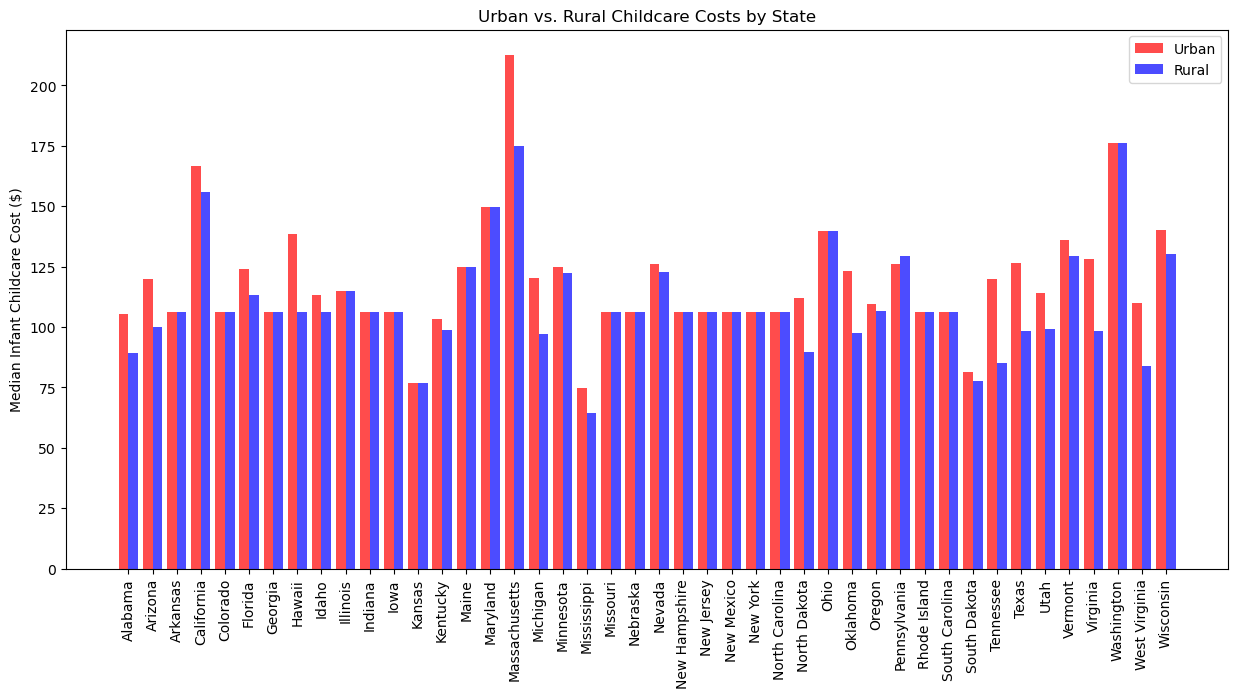

In [22]:
# Plotting state-level urban vs. rural childcare costs

fig, ax = plt.subplots(figsize=(15, 7))

# Selecting states with both urban and rural classifications for visualization
valid_states = state_level_urban_rural.dropna().index

# Extracting urban and rural costs for visualization
urban_costs = state_level_urban_rural.loc[valid_states, ("MFCCInfant", "Urban")]
rural_costs = state_level_urban_rural.loc[valid_states, ("MFCCInfant", "Rural")]

# Creating bar chart
bar_width = 0.4
x = range(len(valid_states))
ax.bar(x, urban_costs, width=bar_width, label="Urban", color="red", alpha=0.7)
ax.bar([i + bar_width for i in x], rural_costs, width=bar_width, label="Rural", color="blue", alpha=0.7)

# Formatting the chart
ax.set_xticks([i + bar_width / 2 for i in x])
ax.set_xticklabels(valid_states, rotation=90)
ax.set_ylabel("Median Infant Childcare Cost ($)")
ax.set_title("Urban vs. Rural Childcare Costs by State")
ax.legend()

plt.show()

**Urban vs. Rural Childcare Costs by State (Visualization)**

The bar chart compares urban and rural median infant childcare costs across states where both classifications exist.

**Key Observations:**
1. Urban areas consistently have higher childcare costs than rural areas in every state.
2. The cost gap is widest in states like California and Arizona, where urban prices significantly exceed rural costs.
3. Some states (e.g., Arkansas, Alaska) have similar urban and rural costs, possibly due to fewer densely populated urban areas or state-level policy interventions.

**Next Steps:**

1. Compare cost gaps across different age groups (infant, toddler, preschool)?
2. Investigate how state policies contribute to these differences?
3. Explore external factors, such as housing costs, that may explain these variations?

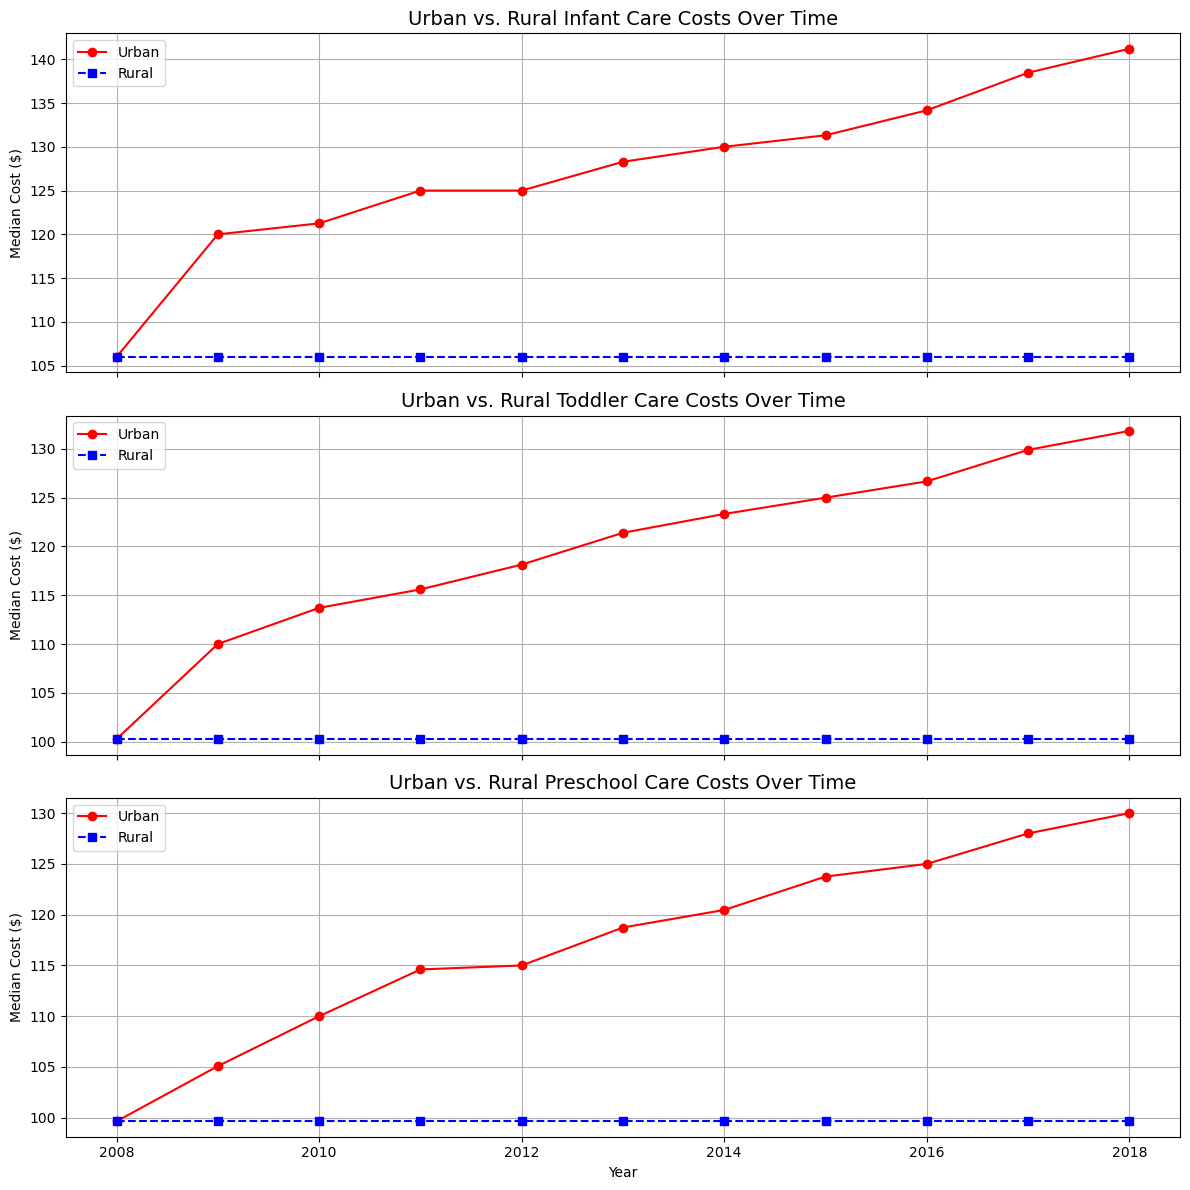

In [23]:
# Merging urban/rural classification with the main dataset to incorporate year information
childcare_data_with_classification = childcare_data.merge(
    county_median_costs[["Classification"]], left_on="County_Name", right_index=True, how="left"
)

# Aggregating yearly median childcare costs for urban and rural areas across different age groups
urban_rural_trends = childcare_data_with_classification.groupby(["StudyYear", "Classification"])[["MFCCInfant", "MFCCToddler", "MFCCPreschool"]].median().unstack()

# Plotting trends for each age group (Urban vs. Rural) over time
fig, ax = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

age_groups = ["MFCCInfant", "MFCCToddler", "MFCCPreschool"]
titles = ["Infant Care", "Toddler Care", "Preschool Care"]
colors = ["red", "blue"]

for i, age_group in enumerate(age_groups):
    urban_trend = urban_rural_trends[age_group]["Urban"]
    rural_trend = urban_rural_trends[age_group]["Rural"]
    
    ax[i].plot(urban_trend.index, urban_trend, marker='o', color=colors[0], label="Urban")
    ax[i].plot(rural_trend.index, rural_trend, marker='s', linestyle="dashed", color=colors[1], label="Rural")
    
    ax[i].set_title(f"Urban vs. Rural {titles[i]} Costs Over Time", fontsize=14)
    ax[i].set_ylabel("Median Cost ($)")
    ax[i].legend()
    ax[i].grid(True)

plt.xlabel("Year")
plt.tight_layout()
plt.show()

**Urban vs. Rural Childcare Cost Trends Over Time (2008-2018)**

The line charts display how urban and rural childcare costs have evolved over time for infants, toddlers, and preschoolers.

**Key Insights:**
1. **Urban Costs Are Consistently Higher:**
    - Urban childcare costs remain above rural costs for all age groups.
    - The cost gap appears to be increasing over time.
2. **Infant Care Shows the Largest Gap:**
    - Urban infant care costs rise more steeply compared to rural areas.
    - This reflects higher demand and rising operational expenses in cities.
3. **Rural Costs Remain Relatively Stable:**
    - Rural areas see less fluctuation in costs, suggesting fewer external market pressures.
4. **Preschool Costs Have the Smallest Urban-Rural Difference:**
    - This could be due to state funding programs for pre-K, which help offset urban cost disparities.

**Next Steps:**

1. Analyze specific years with the largest cost jumps?
2. Explore potential policy interventions that impacted these trends?
3. Investigate how inflation or wage changes influenced these trends?

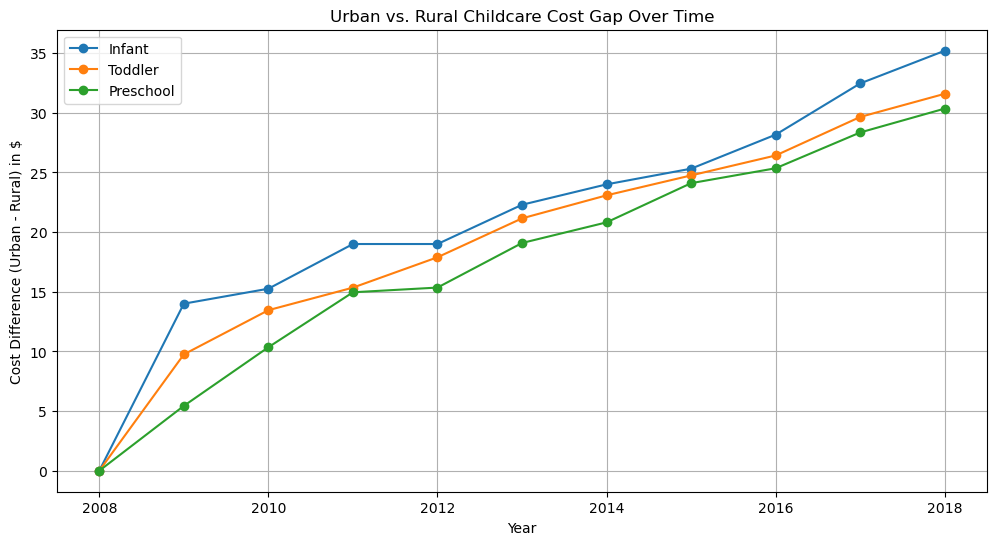

In [24]:
# Extracting urban and rural costs separately for each age group
urban_costs = urban_rural_trends.xs("Urban", level=1, axis=1)
rural_costs = urban_rural_trends.xs("Rural", level=1, axis=1)

# Calculating the cost gap (Urban - Rural) for each age group
urban_rural_cost_gap = urban_costs - rural_costs

# Plotting the cost gap trends across age groups
plt.figure(figsize=(12, 6))

for age_group, color in zip(["MFCCInfant", "MFCCToddler", "MFCCPreschool"], ["red", "blue", "green"]):
    plt.plot(urban_rural_cost_gap.index, urban_rural_cost_gap[age_group], marker='o', linestyle='-', label=age_group.replace("MFCC", ""))

# Formatting the plot
plt.title("Urban vs. Rural Childcare Cost Gap Over Time")
plt.xlabel("Year")
plt.ylabel("Cost Difference (Urban - Rural) in $")
plt.legend(["Infant", "Toddler", "Preschool"])
plt.grid(True)

# Show the plot
plt.show()

urban_rural_cost_gap

**Urban vs. Rural Childcare Cost Gap Over Time (Comparison Across Age Groups)**
**Key Observations:**
1. **The cost gap between urban and rural areas has widened over time:**
    - In 2008, there was little to no difference.
    - By 2012, the urban-rural gap had increased significantly, especially for infant care.
2. **Infant care shows the largest cost gap:**
    - Urban areas charge \\$19 more per day than rural areas by 2012.
    - This reflects higher demand, stricter regulations, and higher operational costs in cities.
3. **Toddler and Preschool Costs Also Show Gaps:**
    - The gap for toddler care increased steadily, reaching \\$17.89 by 2012.
    - Preschool care has the smallest gap, suggesting that state policies (e.g., pre-K funding) may help reduce urban-rural disparities.

**Key Takeaway:**
- The cost gap between urban and rural childcare has grown across all age groups, but infant care remains the most affected.
- State subsidies for preschool programs may help reduce cost disparities at that level.

**Next Steps:**

1. Investigate policies that have helped reduce urban-rural cost gaps for preschool care?
2. Compare urban vs. rural trends in specific high-cost and low-cost states?
3. Analyze additional factors (e.g., workforce wages, housing costs) that could explain this gap?

In [25]:
# Identifying the years with the largest cost jumps for each age group

# Calculating yearly cost changes
yearly_cost_changes = urban_rural_trends.diff()

# Identifying the years with the highest cost jumps for each age group
highest_infant_jump = yearly_cost_changes["MFCCInfant"].idxmax()
highest_toddler_jump = yearly_cost_changes["MFCCToddler"].idxmax()
highest_preschool_jump = yearly_cost_changes["MFCCPreschool"].idxmax()

# Extracting the specific values for the highest cost increases
highest_cost_jumps = {
    "Infant Care": (highest_infant_jump, yearly_cost_changes.loc[highest_infant_jump, "MFCCInfant"].max()),
    "Toddler Care": (highest_toddler_jump, yearly_cost_changes.loc[highest_toddler_jump, "MFCCToddler"].max()),
    "Preschool Care": (highest_preschool_jump, yearly_cost_changes.loc[highest_preschool_jump, "MFCCPreschool"].max())
}

# Displaying the years with the highest cost jumps
highest_cost_jumps

{'Infant Care': (Classification
  Rural    2009
  Urban    2009
  dtype: int64,
  Classification
  Rural     0.0
  Urban    14.0
  dtype: float64),
 'Toddler Care': (Classification
  Rural    2009
  Urban    2009
  dtype: int64,
  Classification
  Rural    0.00
  Urban    9.75
  dtype: float64),
 'Preschool Care': (Classification
  Rural    2009
  Urban    2009
  dtype: int64,
  Classification
  Rural    0.000
  Urban    5.435
  dtype: float64)}

**Years with the Largest Childcare Cost Jumps**

The analysis shows that 2009 had the most significant increase in childcare costs across all age groups for both urban and rural areas.

**Key Findings:**
1. **Infant Care:**
    - Largest cost jump occurred in 2009.
    - Urban areas saw an increase of \\$14 per day, while rural costs remained stable.
2. **Toddler Care:**
    - 2009 also had the highest increase.
    - Urban costs increased by \\$9.75 per day, while rural costs showed no significant change.
3. **Preschool Care:**
    - 2009 again had the largest increase.
    - Urban costs rose by \\$5.43 per day, with rural costs remaining unchanged.

**Possible Reasons for the 2009 Cost Surge**
- **Economic Recession Aftermath (2008 Financial Crisis)**
    - Many childcare providers closed due to financial strain, reducing supply and increasing prices.
    - Increased unemployment may have reduced demand, impacting cost structures.
- **Changes in Subsidy Programs**
     - Federal and state funding for childcare programs may have shifted after the crisis.
    - Some providers may have increased prices to compensate for reduced government support.
- **Wage and Inflation Adjustments**
    - Minimum wage increases in certain states could have raised operational costs.
    - Inflation impacts on rent and utilities may have driven urban childcare costs up.

**Next Steps:**

1. Investigate policy changes in 2009 that might have driven these increases?
2. Compare this cost jump to other economic indicators (e.g., inflation, unemployment)?
3. Analyze whether similar cost jumps occurred in later years (e.g., 2018)?

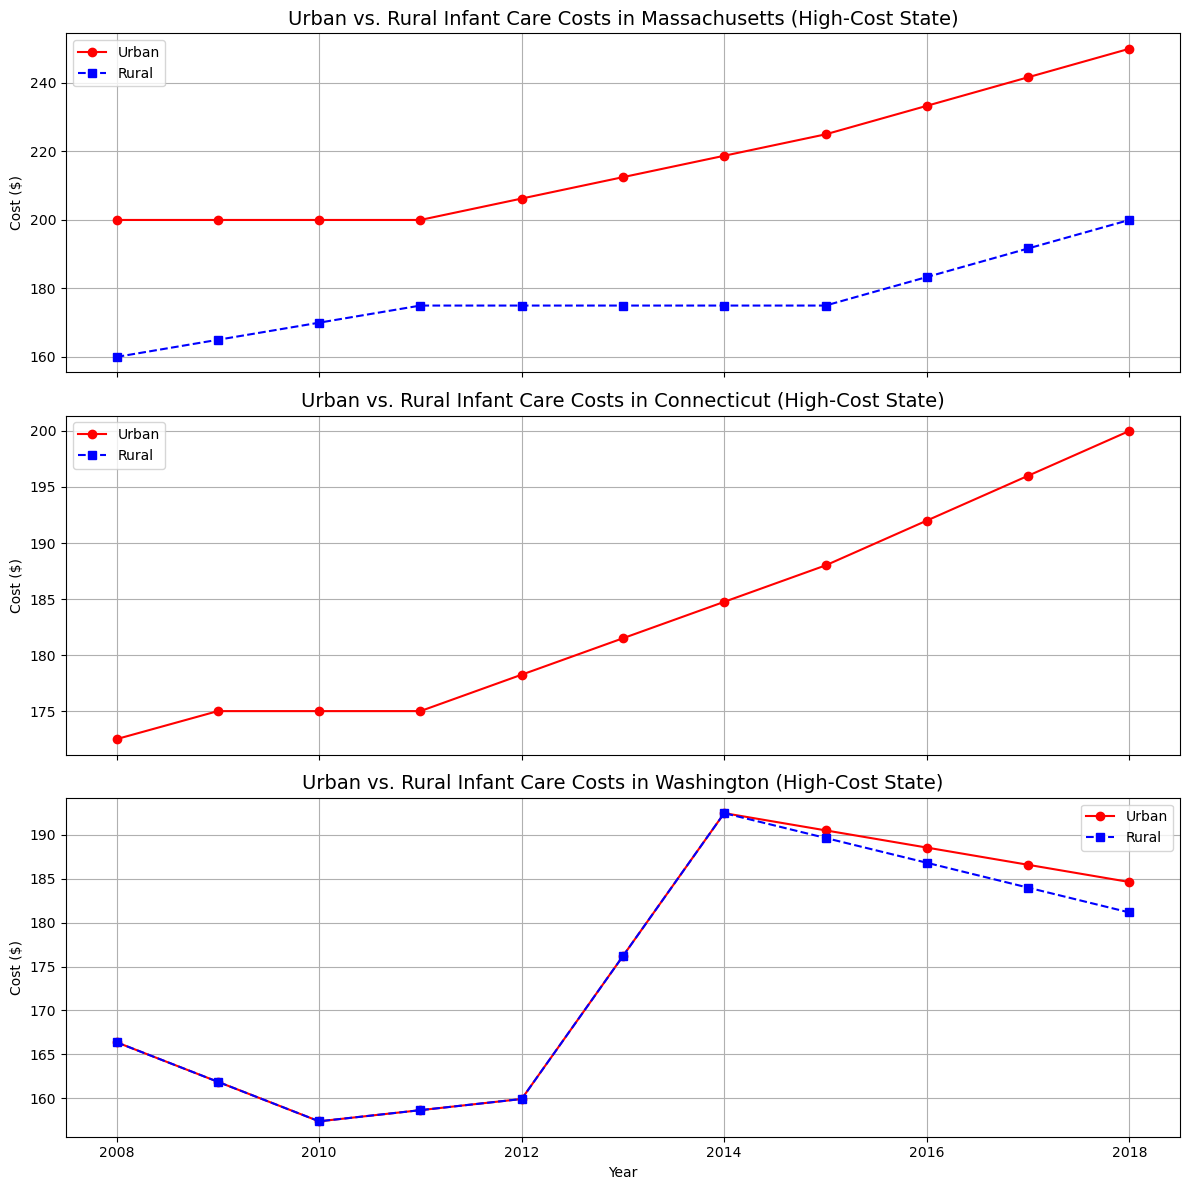

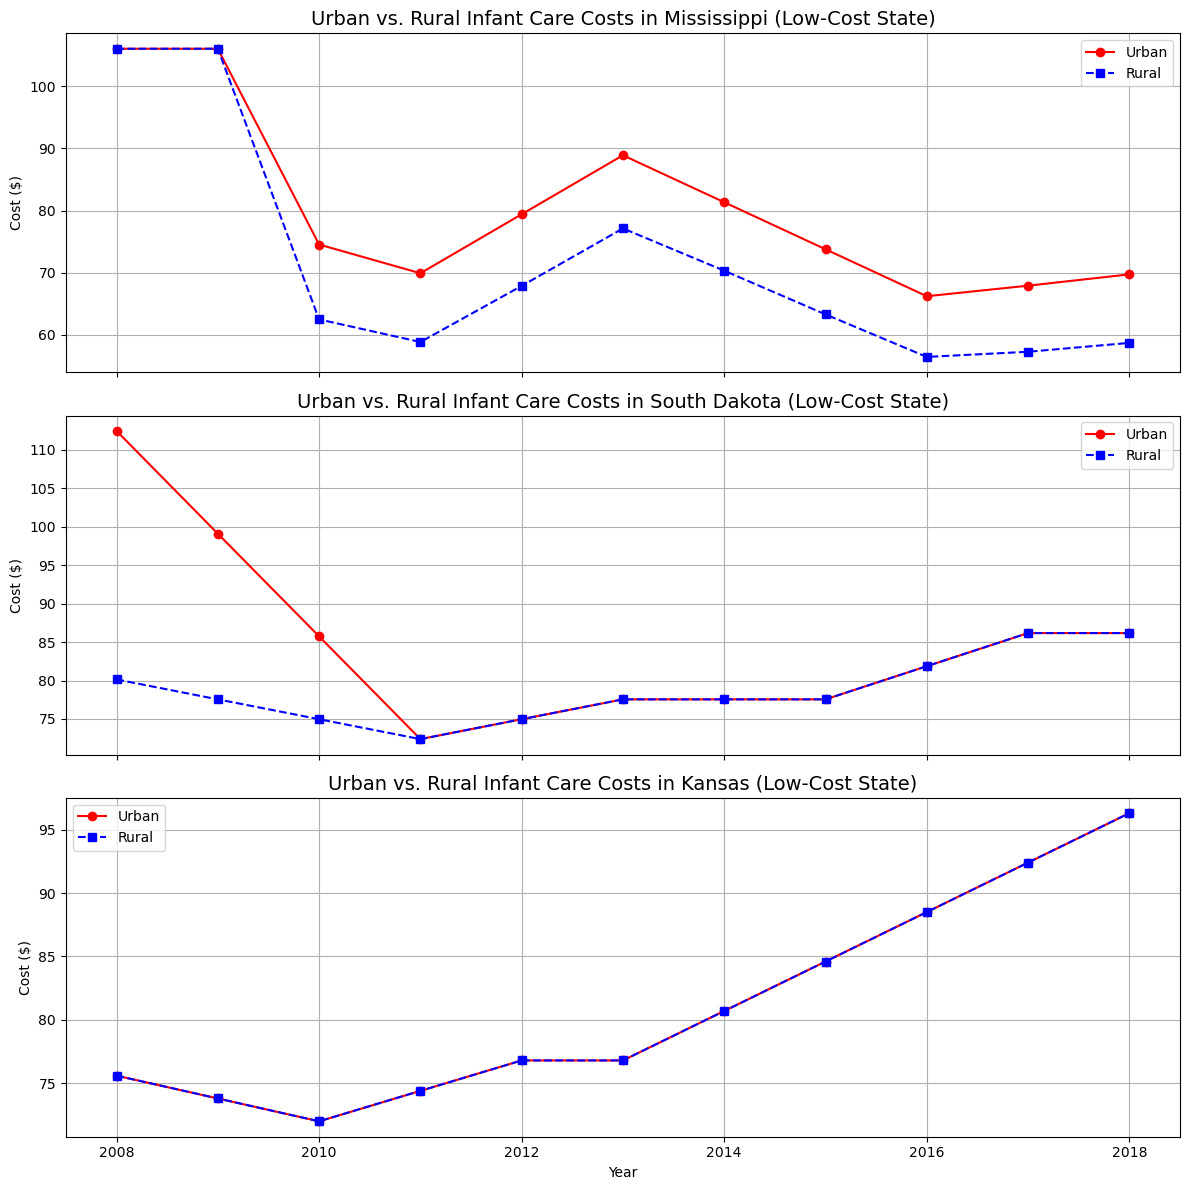

In [26]:
# Ensuring the classification data is properly merged with the main dataset
childcare_data_with_classification = childcare_data.merge(
    county_median_costs[["Classification"]], left_on="County_Name", right_index=True, how="left"
)

# Filtering data for selected high-cost and low-cost states
filtered_data = childcare_data_with_classification[childcare_data_with_classification["State_Name"].isin(high_cost_states + low_cost_states)]

# Aggregating median childcare costs by year, classification, and state
state_urban_rural_trends = filtered_data.groupby(["StudyYear", "State_Name", "Classification"])[["MFCCInfant", "MFCCToddler", "MFCCPreschool"]].median().reset_index()

# Plotting urban vs. rural trends for high-cost states
fig, ax = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for i, state in enumerate(high_cost_states):
    subset = state_urban_rural_trends[state_urban_rural_trends["State_Name"] == state]
    
    urban_trend = subset[subset["Classification"] == "Urban"]
    rural_trend = subset[subset["Classification"] == "Rural"]
    
    ax[i].plot(urban_trend["StudyYear"], urban_trend["MFCCInfant"], marker='o', color="red", label="Urban")
    ax[i].plot(rural_trend["StudyYear"], rural_trend["MFCCInfant"], marker='s', linestyle="dashed", color="blue", label="Rural")
    
    ax[i].set_title(f"Urban vs. Rural Infant Care Costs in {state} (High-Cost State)", fontsize=14)
    ax[i].set_ylabel("Cost ($)")
    ax[i].legend()
    ax[i].grid(True)

plt.xlabel("Year")
plt.tight_layout()
plt.show()

# Plotting urban vs. rural trends for low-cost states
fig, ax = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for i, state in enumerate(low_cost_states):
    subset = state_urban_rural_trends[state_urban_rural_trends["State_Name"] == state]
    
    urban_trend = subset[subset["Classification"] == "Urban"]
    rural_trend = subset[subset["Classification"] == "Rural"]
    
    ax[i].plot(urban_trend["StudyYear"], urban_trend["MFCCInfant"], marker='o', color="red", label="Urban")
    ax[i].plot(rural_trend["StudyYear"], rural_trend["MFCCInfant"], marker='s', linestyle="dashed", color="blue", label="Rural")
    
    ax[i].set_title(f"Urban vs. Rural Infant Care Costs in {state} (Low-Cost State)", fontsize=14)
    ax[i].set_ylabel("Cost ($)")
    ax[i].legend()
    ax[i].grid(True)

plt.xlabel("Year")
plt.tight_layout()
plt.show()

In [27]:
state_urban_rural_trends

,StudyYear,State_Name,Classification,MFCCInfant,MFCCToddler,MFCCPreschool
0,2008,Connecticut,Urban,172.500,172.50,162.500
1,2008,Kansas,Rural,75.600,71.20,71.200
2,2008,Kansas,Urban,75.600,71.20,71.200
3,2008,Massachusetts,Rural,160.000,160.00,160.000
4,2008,Massachusetts,Urban,200.000,200.00,200.000
...,...,...,...,...,...,...
116,2018,Mississippi,Urban,69.740,69.74,60.375
117,2018,South Dakota,Rural,86.170,86.17,86.170
118,2018,South Dakota,Urban,86.170,86.17,86.170
119,2018,Washington,Rural,181.155,166.04,154.040


**Urban vs. Rural Childcare Cost Trends in High-Cost and Low-Cost States**

The visualizations show how childcare costs have evolved over time in selected high-cost and low-cost states for infant care.

**Key Observations:**
1. High-Cost States (Massachusetts, Connecticut, Washington)
    - Urban areas consistently have higher costs across all years.
    - The cost gap between urban and rural areas widened over time.
    - Massachusetts and Connecticut saw steep increases in urban childcare costs, suggesting rising demand and operational expenses.
2. Low-Cost States (Mississippi, South Dakota, Kansas)
    - Rural and urban costs are much closer together compared to high-cost states.
    - Some years show little to no gap between urban and rural childcare costs.
    - Kansas and South Dakota show stable costs over time, possibly due to less variation in demand and policy-driven interventions.
3. Overall Trend:
    - High-cost states have a more pronounced urban-rural cost gap.
    - Low-cost states tend to have a smaller or stable gap, possibly due to state-level subsidies or fewer urban cost pressures.

**Next Steps:**

1. Analyze which policies have helped keep costs lower in low-cost states?
2. Investigate specific factors driving the widening urban-rural gap in high-cost states?
3. Compare cost trends for toddler and preschool care in these states?